In [1]:
# Détecter l'environnement (Colab vs Local)
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

import os

if IN_COLAB:
    # En Colab: cloner le dépôt
    !git clone https://github.com/Stene0/Fichier_colab.git
    data_folder = '/content/Fichier_colab'
else:
    # Localement: utiliser le dossier local
    data_folder = './Fichier_colab'
    # Créer le dossier s'il n'existe pas
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)
        print(f"⚠️  Dossier {data_folder} créé. FICHIER MANQUANT: Téléchargez depuis https://github.com/Stene0/Fichier_colab.git")

print(f"\nFichiers disponibles dans {data_folder}:")
if os.path.exists(data_folder):
    for fichier in os.listdir(data_folder):
        print(f"  ✓ {fichier}")

Running in Google Colab
fatal: destination path 'Fichier_colab' already exists and is not an empty directory.

Fichiers disponibles dans /content/Fichier_colab:
  ✓ README.md
  ✓ ameliorer.html
  ✓ data.ipynb
  ✓ model_solaire.pkl
  ✓ .git
  ✓ data.py
  ✓ api_solaire.py
  ✓ dataset_energie_corrige.xlsx


In [2]:
import os

if IN_COLAB:
    # En Colab: naviguer et mettre à jour le dépôt
    os.chdir('/content/Fichier_colab')
    !git pull
    os.chdir('/content/')
    print("\nContenu mis à jour du dossier Fichier_colab:")
    for fichier in os.listdir('/content/Fichier_colab'):
        print(f"  ✓ {fichier}")
else:
    # Localement: vérifier que les fichiers existent
    if os.path.exists(data_folder):
        print(f"\nFichiers dans {data_folder}:")
        for fichier in os.listdir(data_folder):
            print(f"  ✓ {fichier}")
    else:
        print(f"⚠️  Le dossier {data_folder} n'existe pas encore. Créez-le et téléchargez les fichiers.")

Already up to date.

Contenu mis à jour du dossier Fichier_colab:
  ✓ README.md
  ✓ ameliorer.html
  ✓ data.ipynb
  ✓ model_solaire.pkl
  ✓ .git
  ✓ data.py
  ✓ api_solaire.py
  ✓ dataset_energie_corrige.xlsx


Le `git pull` a mis à jour votre dépôt local avec les derniers fichiers du dépôt distant. Vous devriez maintenant voir les nouveaux fichiers listés ci-dessus.

In [3]:
import pandas as pd
import os

# Construire le chemin du fichier en fonction de l'environnement
if IN_COLAB:
    file_path = '/content/Fichier_colab/dataset_energie_corrige.xlsx'
else:
    file_path = os.path.join(data_folder, 'dataset_energie_corrige.xlsx')

# Vérifier que le fichier existe
if not os.path.exists(file_path):
    print(f"❌ ERREUR: Le fichier {file_path} est introuvable!")
    print(f"📥 Fichier manquant: dataset_energie_corrige.xlsx")
    print(f"📥 Source: https://github.com/Stene0/Fichier_colab.git")
else:
    df = pd.read_excel(file_path)
    print("✓ Data loaded successfully. Here are the first 5 rows:")
    display(df.head())

✓ Data loaded successfully. Here are the first 5 rows:


,CLIENT N,PUISSANCE INSTANTANNE TOTAL,CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT,BATTERIE,PANNEAU,ONDULEUR
0,1,2.703,10.5178,8.538,3.378750,2.703000
1,2,170.815,1721.9084,1002.173,538.096375,430.477100
2,3,18.500,105.9727,68.557,33.116469,26.493175
3,4,7.993,58.2645,50.077,18.207656,14.566125
4,5,6.743,19.6231,14.942,8.428750,6.743000


In [4]:
# Fill missing values in 'PUISSANCE INSTANTANNE TOTAL' based on the user's formula
df['PUISSANCE INSTANTANNE TOTAL'] = df['PUISSANCE INSTANTANNE TOTAL'].fillna(
    df['CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT'] / 20
)

print("DataFrame info after filling missing values in 'PUISSANCE INSTANTANNE TOTAL':")
df.info()

print("\nFirst 5 rows of the DataFrame after imputation:")
display(df.head())

DataFrame info after filling missing values in 'PUISSANCE INSTANTANNE TOTAL':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   CLIENT N                                                                1000 non-null   int64  
 1   PUISSANCE INSTANTANNE TOTAL                                             1000 non-null   float64
 2   CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT  1000 non-null   float64
 3   BATTERIE                                                                1000 non-null   float64
 4   PANNEAU                                                                 1000 non-null   float64
 5   ONDULEUR                                                                1000 non-null   float64
dtypes: f

,CLIENT N,PUISSANCE INSTANTANNE TOTAL,CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT,BATTERIE,PANNEAU,ONDULEUR
0,1,2.703,10.5178,8.538,3.378750,2.703000
1,2,170.815,1721.9084,1002.173,538.096375,430.477100
2,3,18.500,105.9727,68.557,33.116469,26.493175
3,4,7.993,58.2645,50.077,18.207656,14.566125
4,5,6.743,19.6231,14.942,8.428750,6.743000


In [5]:
print("Descriptive statistics for the DataFrame:")
display(df.describe())

Descriptive statistics for the DataFrame:


,CLIENT N,PUISSANCE INSTANTANNE TOTAL,CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT,BATTERIE,PANNEAU,ONDULEUR
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,18.609052,151.337040,113.185211,47.001232,38.127881
std,288.819436,28.389085,314.954566,238.711826,97.608876,78.616509
min,1.000000,0.573030,3.901800,2.375000,1.880700,1.534000
25%,250.750000,4.867250,18.900600,13.461500,6.847137,5.492950
50%,500.500000,7.698500,39.578000,31.906000,12.430703,9.955063
75%,750.250000,18.918750,135.490275,99.276250,42.344625,33.872569
max,1000.000000,199.360000,2976.079400,2408.444000,930.024813,744.019850


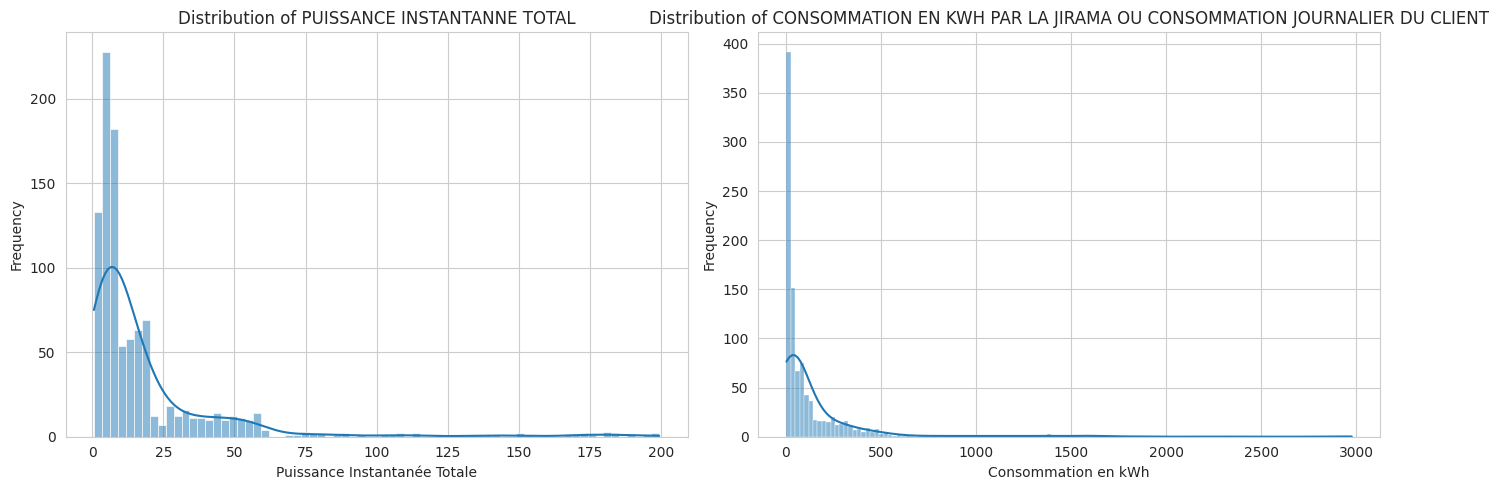

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for 'PUISSANCE INSTANTANNE TOTAL'
sns.histplot(df['PUISSANCE INSTANTANNE TOTAL'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of PUISSANCE INSTANTANNE TOTAL')
axes[0].set_xlabel('Puissance Instantanée Totale')
axes[0].set_ylabel('Frequency')

# Histogram for 'CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT'
sns.histplot(df['CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT')
axes[1].set_xlabel('Consommation en kWh')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Correlation Matrix:


,CLIENT N,PUISSANCE INSTANTANNE TOTAL,CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT,BATTERIE,PANNEAU,ONDULEUR
CLIENT N,1.000000,-0.046478,-0.045107,-0.038286,-0.045746,-0.045284
PUISSANCE INSTANTANNE TOTAL,-0.046478,1.000000,0.957550,0.941468,0.955401,0.957394
CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT,-0.045107,0.957550,1.000000,0.989434,0.998685,0.999968
BATTERIE,-0.038286,0.941468,0.989434,1.000000,0.988981,0.989411
PANNEAU,-0.045746,0.955401,0.998685,0.988981,1.000000,0.998730
ONDULEUR,-0.045284,0.957394,0.999968,0.989411,0.998730,1.000000


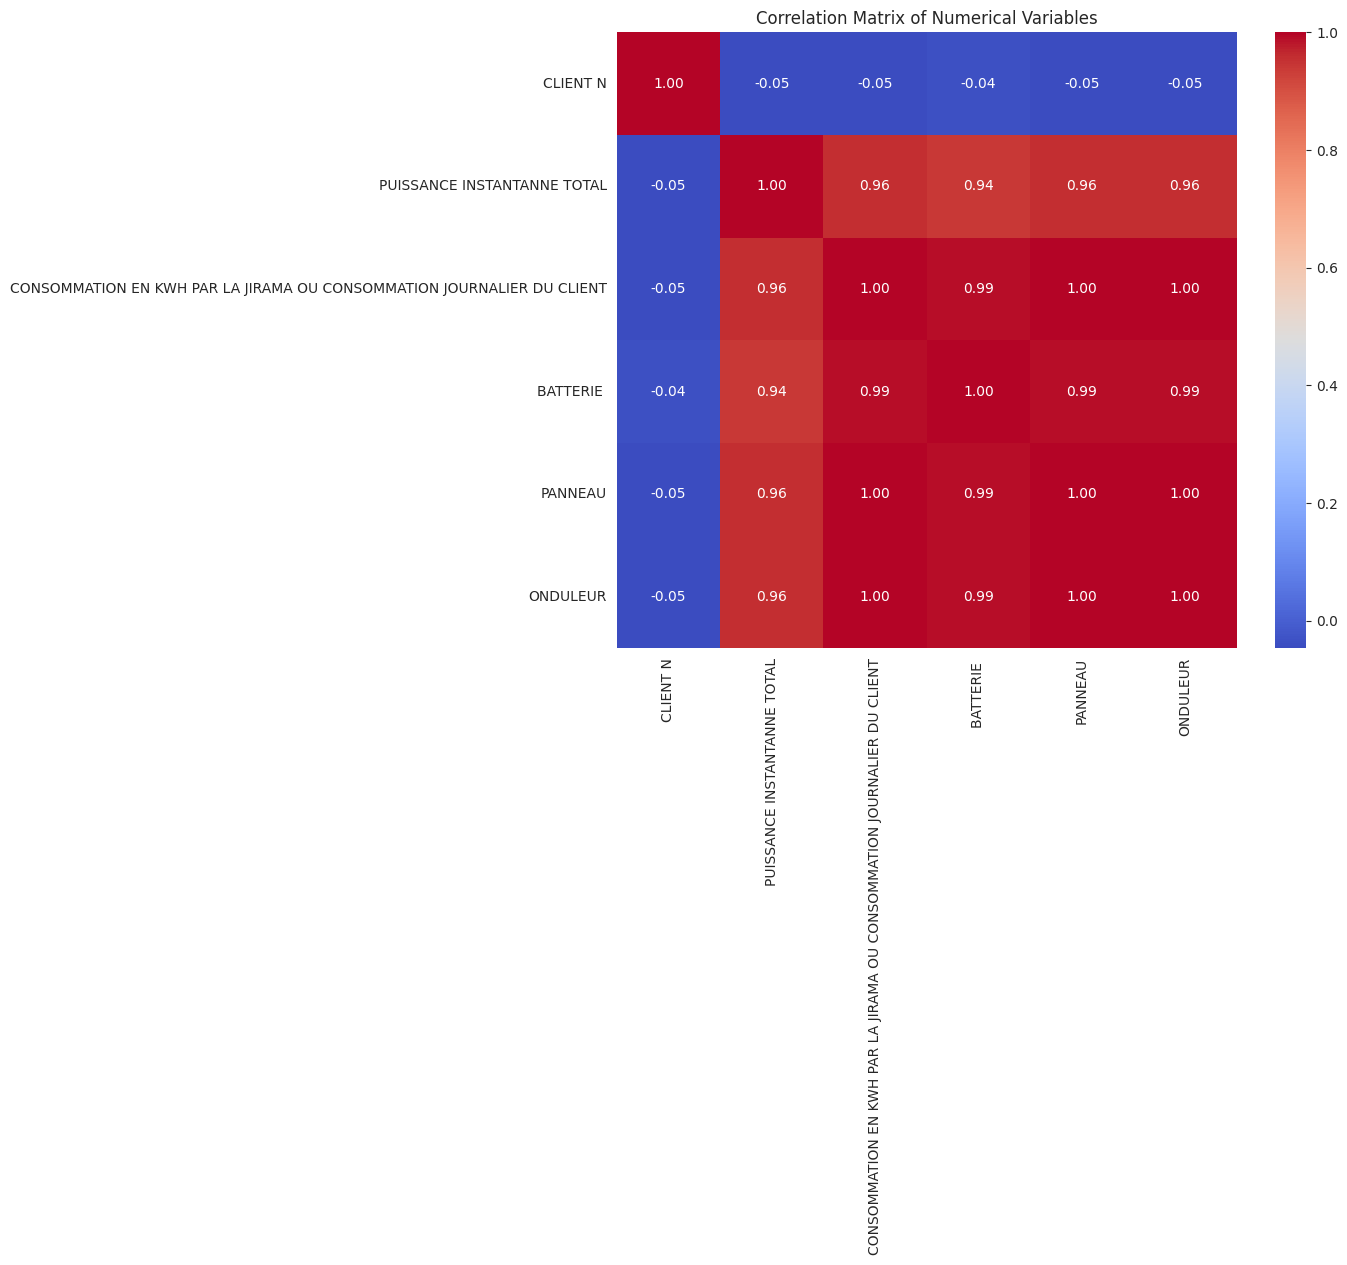

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = df.corr(numeric_only=True)

print("Correlation Matrix:")
display(correlation_matrix)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

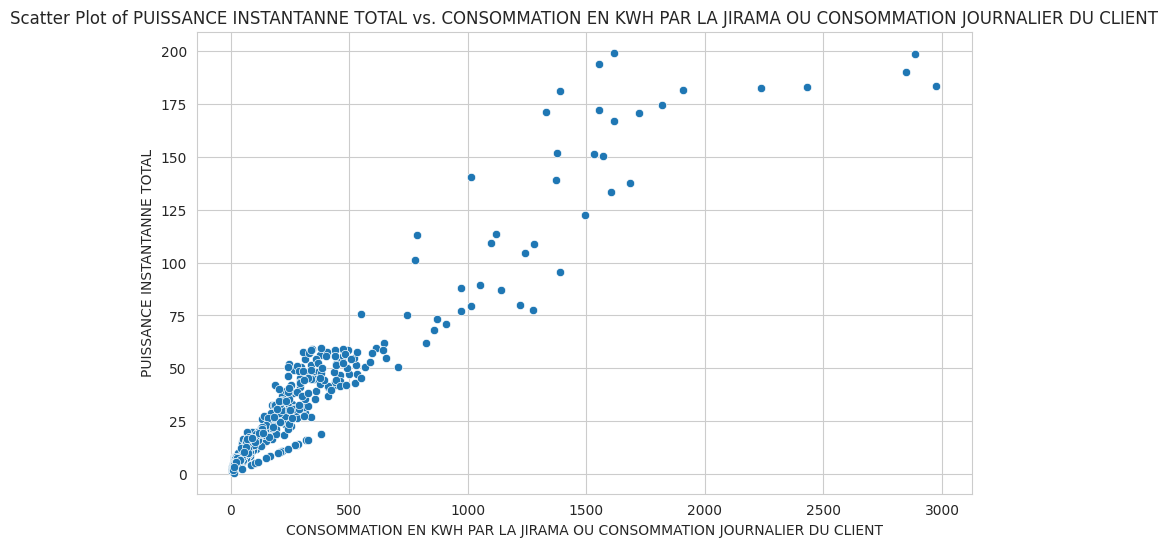

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the relationship between the two variables
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT', y='PUISSANCE INSTANTANNE TOTAL', data=df)
plt.title('Scatter Plot of PUISSANCE INSTANTANNE TOTAL vs. CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT')
plt.xlabel('CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT')
plt.ylabel('PUISSANCE INSTANTANNE TOTAL')
plt.grid(True)
plt.show()


Ce nuage de points visualise la relation directe entre la 'PUISSANCE INSTANTANNE TOTAL' et la 'CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT'.

*   Chaque point représente une observation dans votre DataFrame.
*   L'axe des x montre la 'CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT'.
*   L'axe des y montre la 'PUISSANCE INSTANTANNE TOTAL'.

En observant la répartition des points, nous pouvons visuellement identifier s'il existe une corrélation positive (les points montent de gauche à droite), négative (les points descendent de gauche à droite), ou aucune corrélation claire.

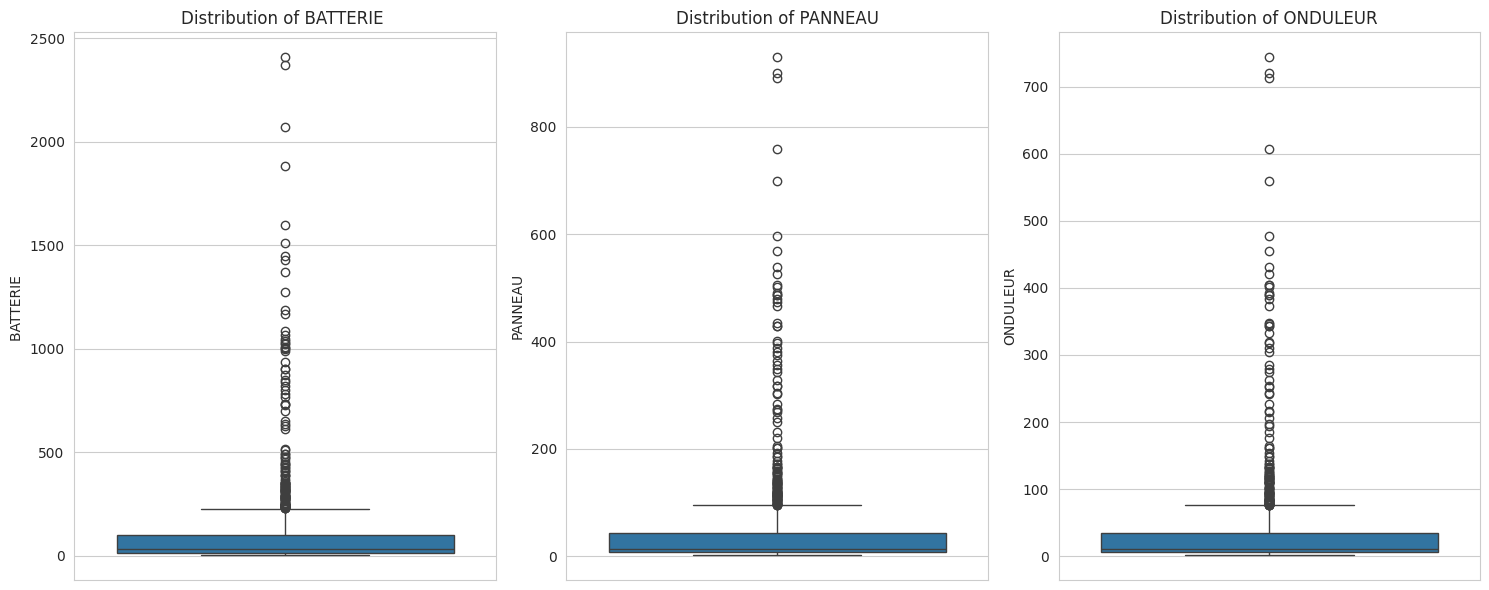

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to plot (excluding 'CLIENT N' and the ones already plotted extensively)
numerical_cols = ['BATTERIE ', 'PANNEAU', 'ONDULEUR'] # Corrected column name here

# Create subplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(5 * len(numerical_cols), 6))

# Ensure axes is an array even if there's only one column
if len(numerical_cols) == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Ces diagrammes en boîte (box plots) montrent la distribution de chaque variable :

*   La **ligne au milieu** de la boîte représente la médiane (50ème percentile).
*   Les **bords de la boîte** représentent le premier quartile (25ème percentile) et le troisième quartile (75ème percentile).
*   Les **moustaches (whiskers)** s'étendent aux valeurs minimales et maximales à l'intérieur de 1,5 fois l'intervalle interquartile (IQR).
*   Les **points individuels** au-delà des moustaches représentent les valeurs aberrantes (outliers).

Cette visualisation nous permet de rapidement identifier la plage de valeurs, la symétrie de la distribution et la présence de valeurs extrêmes pour 'BATTERIE', 'PANNEAU' et 'ONDULEUR'.

In [10]:
print(df.columns)

Index(['CLIENT N', 'PUISSANCE INSTANTANNE TOTAL',
       'CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT',
       'BATTERIE ', 'PANNEAU', 'ONDULEUR'],
      dtype='object')


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Define feature columns (X) and target columns (y)
# Ensure column names match exactly, including any leading/trailing spaces
X_columns = [
    'CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT',
    'PUISSANCE INSTANTANNE TOTAL'
]
y_columns = ['BATTERIE ', 'PANNEAU', 'ONDULEUR'] # Using corrected column name for BATTERIE

X = df[X_columns]
y = df[y_columns]

print("Features (X) shape:", X.shape)
print("Targets (y) shape:", y.shape)

Features (X) shape: (1000, 2)
Targets (y) shape: (1000, 3)


In [12]:
# Split the data into training and testing sets
# We'll use 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())

print("\nFirst 5 rows of y_train:")
display(y_train.head())

X_train shape: (800, 2)
X_test shape: (200, 2)
y_train shape: (800, 3)
y_test shape: (200, 3)

First 5 rows of X_train:


,CONSOMMATION EN KWH PAR LA JIRAMA OU CONSOMMATION JOURNALIER DU CLIENT,PUISSANCE INSTANTANNE TOTAL
29,21.3007,6.888
535,146.1732,20.836
695,95.3480,12.305
557,13.5616,4.172
836,481.0489,56.965



First 5 rows of y_train:


,BATTERIE,PANNEAU,ONDULEUR
29,14.350,9.019900,6.888000
535,114.318,45.679125,36.543300
695,75.900,29.796250,23.837000
557,10.916,5.215000,4.172000
836,441.382,155.283800,120.262225


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize the RandomForestRegressor model
# Using a random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nR-squared (R2) score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

print("\nFirst 5 predictions:")
display(pd.DataFrame(y_pred, columns=y_test.columns).head())

print("\nFirst 5 actual values from test set:")
display(y_test.head())

Model training complete.

R-squared (R2) score: 0.9806
Mean Absolute Error (MAE): 7.6718

First 5 predictions:


,BATTERIE,PANNEAU,ONDULEUR
0,21.31054,9.457146,7.455612
1,224.61861,93.003298,74.643367
2,32.04230,16.007315,12.575548
3,12.67047,6.704700,5.417127
4,476.40211,194.971299,155.869170



First 5 actual values from test set:


,BATTERIE,PANNEAU,ONDULEUR
521,22.941,9.745600,7.574000
737,239.182,95.160313,76.128250
740,40.720,13.244500,12.466900
660,13.977,6.755000,5.404000
411,635.803,220.265156,176.212125


In [16]:
from google.colab import files
import os

html_file = '/content/Fichier_colab/ameliorer.html'

if os.path.exists(html_file):
    print(f"Préparation du téléchargement de {html_file}...")
    files.download(html_file)
else:
    print(f"Erreur : Le fichier {html_file} n'existe pas dans le dossier Colab.")

Préparation du téléchargement de /content/Fichier_colab/ameliorer.html...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import joblib

# Save the trained model
joblib.dump(model, 'model_solaire.pkl')

print("Model 'model_solaire.pkl' saved successfully.")

Model 'model_solaire.pkl' saved successfully.


In [17]:
from google.colab import files

# Download the model file
files.download('model_solaire.pkl')

print("Downloading 'model_solaire.pkl'...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
!pip install flask flask-cors pyngrok -q

In [19]:
from pyngrok import ngrok

# Remplace par ton token depuis https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3Bn1QWzTTd8Lc52q5TEVyEr3Rdp_77JKi8iEf3AoGFhk9nB3Q")
print("✅ Token ngrok configuré")

✅ Token ngrok configuré


In [32]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import joblib
import numpy as np
import threading
import time

app = Flask(__name__)
CORS(app)

model = joblib.load('model_solaire.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        consommation = float(data['consommation_kwh'])
        puissance = float(data['puissance_kw'])

        X = np.array([[consommation, puissance]])
        prediction = model.predict(X)[0]

        raw_batt = float(prediction[0])
        raw_pan  = float(prediction[1])
        raw_ond  = float(prediction[2])

        # LOGIQUE DE CORRECTION D'ÉCHELLE
        # Si raw_pan est petit (ex: 3.0), c'est des kWc. Si c'est grand (ex: 3000), c'est des Wc.
        if raw_pan < 100:
            p_kwc = round(raw_pan, 2)
            p_wc = round(raw_pan * 1000, 0)
        else:
            p_wc = round(raw_pan, 0)
            p_kwc = round(raw_pan / 1000, 2)

        b_kwh = round(raw_batt, 2)
        o_kw  = round(raw_ond, 2)

        return jsonify({
            "batterie_kwh": b_kwh,
            "panneau_kwc":  p_kwc,
            "panneau_wc":   p_wc,
            "onduleur_kw":  o_kw,
            "conseil": f"Installation standard : {p_kwc} kWc de panneaux et {b_kwh} kWh de batterie."
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 400

ngrok.kill()
time.sleep(2)
threading.Thread(target=lambda: app.run(port=5000, use_reloader=False), daemon=True).start()
tunnel = ngrok.connect(5000)
url_publique = tunnel.public_url
print(f"\n✅ API CORRIGÉE : {url_publique}")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.



✅ API CORRIGÉE : https://supersphenoid-pipiest-kimber.ngrok-free.dev


In [33]:
import requests

# Test /predict avec les nouvelles corrections
payload = {"consommation_kwh": 5.0, "puissance_kw": 2.5}
try:
    r = requests.post(f"{url_publique}/predict", json=payload)
    print("Résultat de la nouvelle API :")
    import json
    print(json.dumps(r.json(), indent=4, ensure_ascii=False))
except Exception as e:
    print(f"Erreur de connexion : {e}")

Résultat de la nouvelle API :
{
    "batterie_kwh": 3.52,
    "conseil": "Installation standard. Panneau 3 kWc + batterie 3.5 kWh + onduleur 2.2 kW.",
    "onduleur_kw": 2.23,
    "panneau_kwc": 0.0,
    "panneau_wc": 3.0
}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [34]:
import os

# Nom du fichier HTML selon l'environnement
if IN_COLAB:
    html_file = '/content/Fichier_colab/ameliorer.html'
else:
    html_file = os.path.join(data_folder, 'ameliorer.html')

print(f"🔎 Chemin HTML utilisé : {html_file}")

if os.path.exists(html_file):
    with open(html_file, 'r') as f:
        content = f.read()

    # Remplacement de l'URL localhost ou ancienne ngrok par la nouvelle URL active
    # On cible spécifiquement la base de l'URL pour être sûr de la redirection
    import re
    # On remplace soit localhost, soit une ancienne url ngrok-free.dev
    new_content = re.sub(r'http://localhost:5000', url_publique, content)
    new_content = re.sub(r'https://[a-z0-9-]+\.ngrok-free\.dev', url_publique, new_content)

    with open(html_file, 'w') as f:
        f.write(new_content)
    print(f"✅ Fichier {html_file} mis à jour.")
    print(f"🌐 Nouvelle URL configurée dans le HTML : {url_publique}")
else:
    print(f"❌ Le fichier {html_file} est introuvable.")

🔎 Chemin HTML utilisé : /content/Fichier_colab/ameliorer.html
✅ Fichier /content/Fichier_colab/ameliorer.html mis à jour.
🌐 Nouvelle URL configurée dans le HTML : https://supersphenoid-pipiest-kimber.ngrok-free.dev


In [35]:
import IPython
from google.colab import output
import logging

# Désactiver les logs d'avertissement pour nettoyer l'affichage
logging.getLogger('werkzeug').setLevel(logging.ERROR)

# Utiliser iframe au lieu de window pour éviter l'avertissement de sécurité
output.serve_kernel_port_as_iframe(5000)

# Corrected file path
html_file_path = '/content/Fichier_colab/ameliorer.html'

with open(html_file_path, 'r') as f:
    html_content = f.read()

print("--- Interface de Dimensionnement Solaire ---")
IPython.display.HTML(html_content)

<IPython.core.display.Javascript object>

--- Interface de Dimensionnement Solaire ---
